# Gated Recurrent Network Example

This notebook contains an example of training and evaluating a GRU using battery lifetime data

## Battery Life Dataset

The example uses the NASA battery life dataset.  You can download a version in CSV format from Kaggle here :
https://www.kaggle.com/datasets/patrickfleith/nasa-battery-dataset/data

Just unzip the downloaded file into the same folder as this notebook.

The data comprises a file containing time series data for each charge or discharge cycle, as well as impedance measurements made between cycles, and a file of metadata.

## Initial Inspection

In this example, we will only use the metadata file, which includes the capacity of each battery at the start of each cycle.  First we load as a dataframe.

In [1]:
import numpy as np
import pandas as pd

# read the metadata file
metadata_df = pd.read_csv("cleaned_dataset/metadata.csv")
metadata_df

# replace any NaN with zero
metadata_df.fillna(0)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,0,0
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,0,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,0,0,0
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,0,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,0,0
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,0,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,0,0
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,0,0,0
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,0,0


In [2]:
# get the unique IDs of each battery
ids = sorted(set(metadata_df['battery_id'].to_numpy()))

# two batteries do not include Capacity data, so remove them
ids.remove("B0050")
ids.remove("B0052")

print(ids)

['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0051', 'B0053', 'B0054', 'B0055', 'B0056']


First let's look at the capacity as a function of cycle for an individual battery

In [3]:
# get the State of Health (SOH) as function of discharge cycle for a given battery
# SOH is just defined as the current capacity divided by original capacity
def getSOH(df, id):
    # this just selects rows with given battery ID and of type discharge
    tmp_df = df.loc[ (df['battery_id']==id) & (df['type']=='discharge') ]

    # make sure this dataframe is in test order
    tmp_df.sort_values(by=['test_id'])

    # to_numeric converts from string to float, and to_numpy converts to a simple array
    capacity = pd.to_numeric(tmp_df['Capacity'], errors='coerce').to_numpy()

    ## remove any zeros
    #capacity = capacity[capacity != 0.]
        
    soh = capacity / np.max(capacity)
    return soh
    
print(getSOH(metadata_df, "B0048"))

[1.         0.90934703 0.90405689 0.89161393 0.88170132 0.87512855
 0.87560366 0.8711681  0.86413881 0.85479191 0.84786474 0.83852493
 0.85625435 0.85588672 0.8469699  0.8393352  0.82929162 0.8169597
 0.81063081 0.         0.82773711 0.79518341 0.79087832 0.78228028
 0.78379096 0.77359398 0.76917516 0.76813067 0.75959879 0.76186166
 0.75342284 0.74426275 0.74791031 0.78631607 0.79316011 0.77736868
 0.77666899 0.7643796  0.75428087 0.75314623 0.75271752 0.74191363
 0.73849395 0.73502505 0.7260493  0.72060761 0.72690736 0.72109641
 0.71704034 0.71867533 0.70727493 0.71418368 0.69824222 0.
 0.75956526 0.76350226 0.75226972 0.7435537  0.74304135 0.7363022
 0.74037841 0.74709418 0.74086915 0.72952435 0.7287198  0.
 0.78400297 0.76545564 0.75724838 0.75512125 0.74638209 0.73771451]


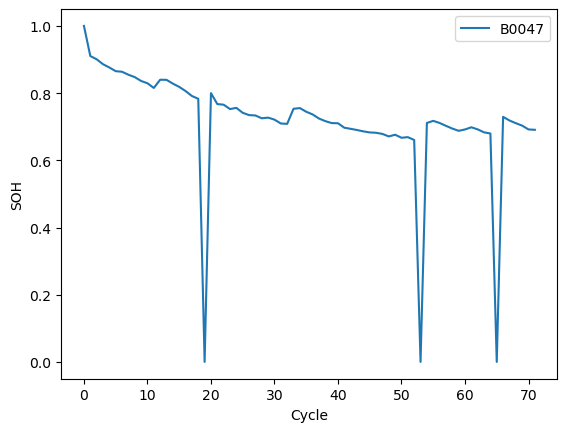

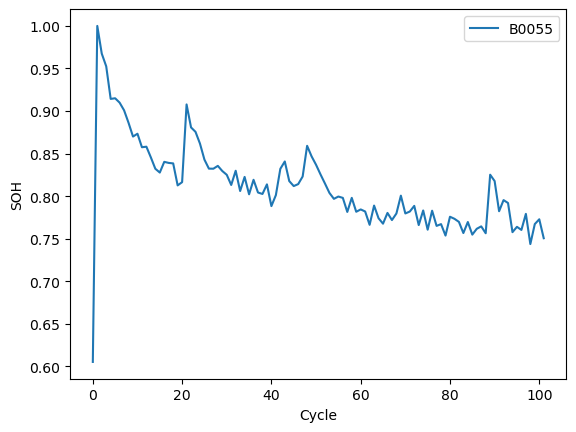

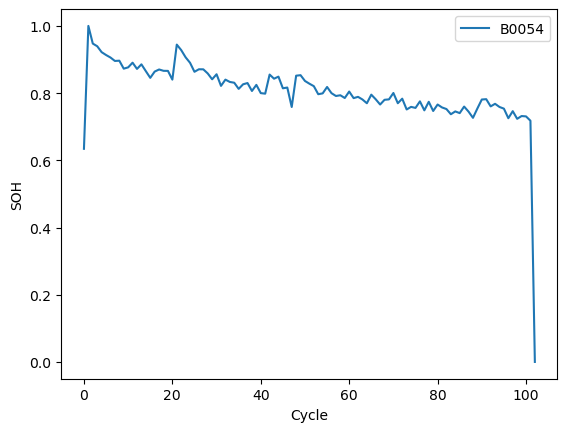

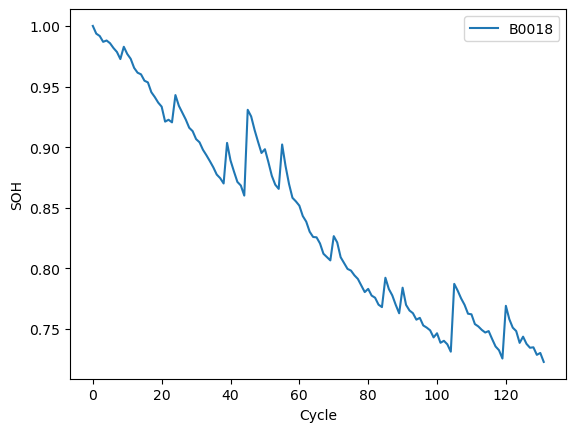

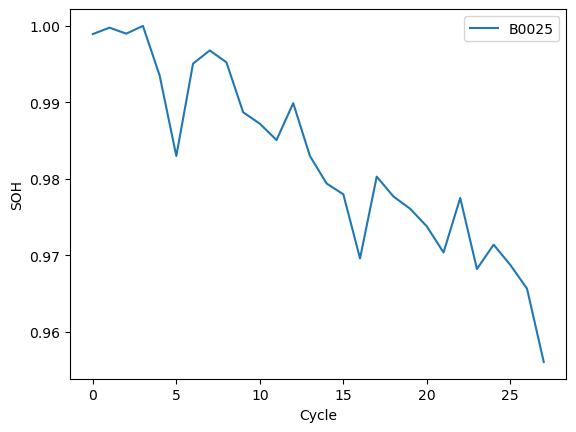

In [4]:
# now plot that as a time series
import matplotlib.pyplot as plt

def plotSeries(soh, id):
    x = np.arange(0, len(soh))
    plt.plot(x, soh, label=id)
    plt.xlabel('Cycle')
    plt.ylabel('SOH')
    plt.legend()
    plt.savefig(id+".pdf")
    plt.show()

# for i in ids:
#     plotSeries(getSOH(metadata_df, i),i)

soh = getSOH(metadata_df, "B0047")
plotSeries(soh, "B0047")

soh = getSOH(metadata_df, "B0055")
plotSeries(soh, "B0055")

soh = getSOH(metadata_df, "B0054")
plotSeries(soh, "B0054")

soh = getSOH(metadata_df, "B0018")
plotSeries(soh, "B0018")

soh = getSOH(metadata_df, "B0025")
plotSeries(soh, "B0025")

# Data Preparation

Next we prepare the time series data for input to a GRU model.

First, we compute SOH for all batteries, put the results in a Python list and split that into training and test datasets.

In [5]:
# get all the data
def getData(df, ids):
    data = []
    for id in ids:
        arr = getSOH(metadata_df, id)
        data.append(arr)
    return data

data = getData(metadata_df, ids)

# train/test split
data_train = data[0:17]
data_test = data[17:34]

The model will require the input data to comprise a set of sequences of fixed length.  We need to produce 3D tensors for input data, $\textbf{X}$, and target, $\textbf{y}$, of shape : 
$(N_{samples}, L_{sequence}, N_{features})$

Currently the battery capacity data is of varying length.  The standard approach to produce fixed length sequences is a "sliding window" algorithm - essentially this extracts all possible fixed length sequences from the data.  In this problem, we will use a window of length 5 to extract the input data, $\textbf{X}$, and use the next single timestep as the target $\textbf{y}$.  So both the input and output tensors will be of shape $(N_{samples}, 5, 1)$.

In the next cell we create the fixed length sequences for training and validation and output 3D numpy arrays with the required shapes.

In [6]:
# now create fixed length sequences
def getSequences(data, lseq):

    # input data is a 3D array : sequence length x N sequences x 1 input variable
    x = np.zeros((0, lseq, 1))
    # output data is also a 3D array : 1 sequence element x N sequences x 1 output variable
    y = np.zeros((0, 1, 1))

    print(x.shape)
    print(y.shape)
    
    for d in data:
        for i in range(len(d)-lseq-1):
            # take a slice from d starting at i, of length lseq, d[i:i+lseq]
            x_seq = d[i:i+lseq].reshape((1,lseq,1))
            # get the next element in the sequence
            y_seq = d[i+lseq+1].reshape((1,1,1))

            # now append to the output arrays
            x = np.concatenate((x, x_seq), axis=0)
            y = np.concatenate((y, y_seq), axis=0)

    return x,y

x_train, y_train = getSequences(data_train, 5)
x_test, y_test = getSequences(data_test, 5)

(0, 5, 1)
(0, 1, 1)
(0, 5, 1)
(0, 1, 1)


We just need to convert to pytorch Tensors, and again we'll use the TensorDataset and DataLoader for convenience as previous examples.

In [7]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# check these have the expected shapes
print(x_train_tensor.shape)
print(y_train_tensor.shape)

# check for NaNs which will confuse our model later
# (if we had not removed "B0050" and "B0052" these would print True and the loss computation would also show nans)
print(torch.any(torch.isnan(x_train_tensor)))
print(torch.any(torch.isnan(y_train_tensor)))
print(torch.any(torch.isnan(x_test_tensor)))
print(torch.any(torch.isnan(y_test_tensor)))

# produce TensorDatasets
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# and DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, drop_last = True, shuffle=True) # Shuffle for training
val_loader = DataLoader(test_dataset, batch_size=batch_size, drop_last = True, shuffle=False) # No shuffle for validation

torch.Size([1491, 5, 1])
torch.Size([1491, 1, 1])
tensor(False)
tensor(False)
tensor(False)
tensor(False)


## GRU Model implementation

Now we are ready to implement the model - a very simple Gated Recurrent Unit.  We will also implement a Trainer class in the same way as previous PyTorch NN examples.


In [8]:
# now implement a GRU
import math
import torch.nn as nn
import torch.nn.functional as F

class SimpleGRUModel(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=1, num_layers=1, batch_first=True)
        self.fc = nn.Linear(1, 1)
    
    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 1)  # initialise hidden state, expects Tensor size (1, N_batch, N_hidden)
        out,_ = self.gru(x) #, h0)
        y_hat = self.fc(out)
        return out

    def training_step(self, batch):
        # a training step means computing the output from a batch
        x, y = batch
        y_hat = self(x)
        # print("target y: ",y[:,0,:])
        # print("model  y: ",y_hat[:,0,:])
        loss = nn.L1Loss()(y_hat[:,0,:], y[:,0,:])
        if math.isnan(loss.item()):
            print(x)
        return loss

In [28]:
class Trainer():
    def __init__(self, model, n_epochs, lr, train_loader, val_loader):
        self.model = model
        self.n_epochs = n_epochs
        self.loss_train = np.zeros(n_epochs)
        self.loss_val   = np.zeros(n_epochs)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.optimizer = torch.optim.SGD(self.model.parameters(), lr=lr)
        #self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        print(self.train_loader)
        
    def fit(self):
        for epoch in range(self.n_epochs):

            # this is the training phase
            loss_t = []
            for batch in self.train_loader:
                loss = self.model.training_step(batch)
                loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()
                loss_t.append(loss.item())
            self.loss_train[epoch] = np.array(loss_t).mean()

            # this is the validation phase
            # just calculate the loss, no updating weights !
            loss_v = []
            for batch in self.val_loader:
                loss = self.model.training_step(batch).item()
                loss_v.append(loss)
            self.loss_val[epoch] = np.array(loss_v).mean()
            
            # add some printout every few epochs
            if (epoch+1) % 20 == 0 or epoch == self.n_epochs-1:
                print("Epoch [{}], val_loss: {:.4f}".format(epoch+1, self.loss_val[epoch]))

In the next cell we train the model, again this is familiar code

In [33]:
model=SimpleGRUModel()
trainer = Trainer(model, 500, 1e-3, train_loader, val_loader)
trainer.fit()

Epoch [20], val_loss: 0.2557
Epoch [40], val_loss: 0.2226
Epoch [60], val_loss: 0.1993
Epoch [80], val_loss: 0.1858
Epoch [100], val_loss: 0.1798
Epoch [120], val_loss: 0.1771
Epoch [140], val_loss: 0.1757
Epoch [160], val_loss: 0.1747
Epoch [180], val_loss: 0.1740
Epoch [200], val_loss: 0.1735
Epoch [220], val_loss: 0.1730
Epoch [240], val_loss: 0.1725
Epoch [260], val_loss: 0.1720
Epoch [280], val_loss: 0.1714
Epoch [300], val_loss: 0.1708
Epoch [320], val_loss: 0.1702
Epoch [340], val_loss: 0.1696
Epoch [360], val_loss: 0.1690
Epoch [380], val_loss: 0.1683
Epoch [400], val_loss: 0.1676
Epoch [420], val_loss: 0.1670
Epoch [440], val_loss: 0.1663
Epoch [460], val_loss: 0.1655
Epoch [480], val_loss: 0.1648
Epoch [500], val_loss: 0.1641


And we can check the training and validation loss to see that the model is being trained sensibly

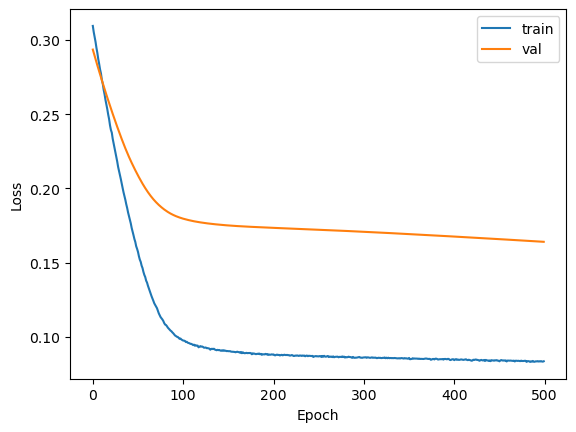

In [34]:
x = np.arange(0,trainer.n_epochs)

plt.plot(x, trainer.loss_train, label="train")
plt.plot(x, trainer.loss_val, label="val")
#plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss.pdf")
plt.show()

## Model Performance

First we're going to run full length sequences of validation data through the model, to check the output is qualitatively as expected.

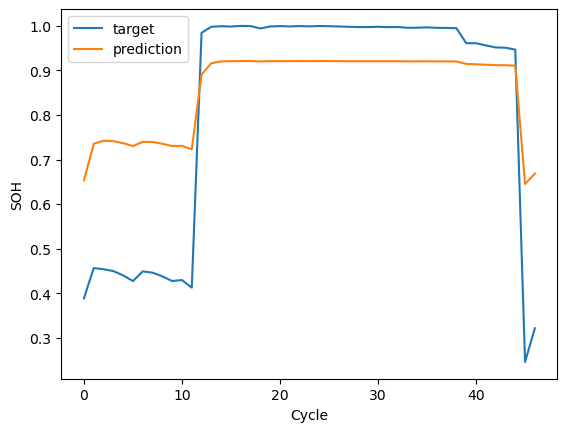

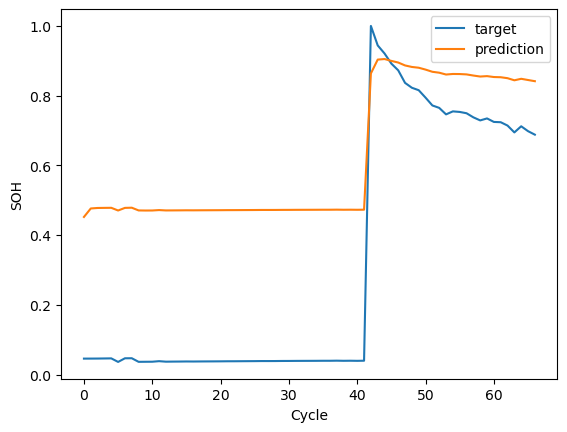

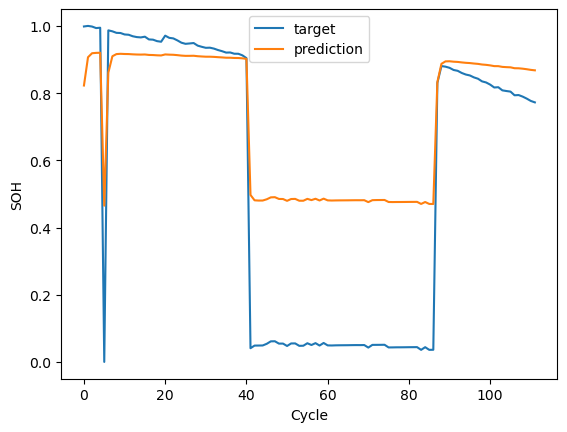

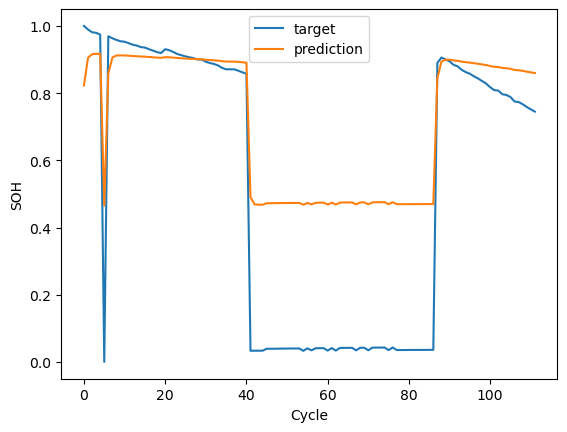

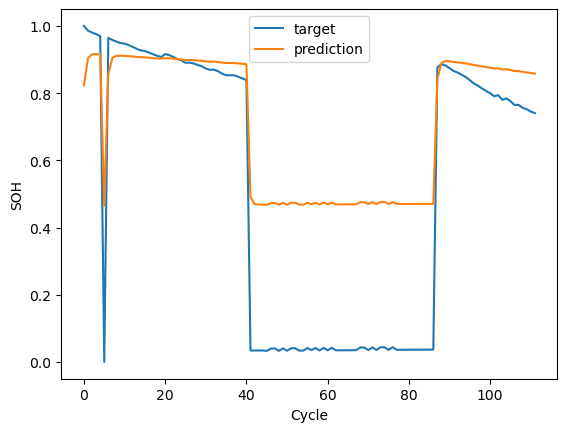

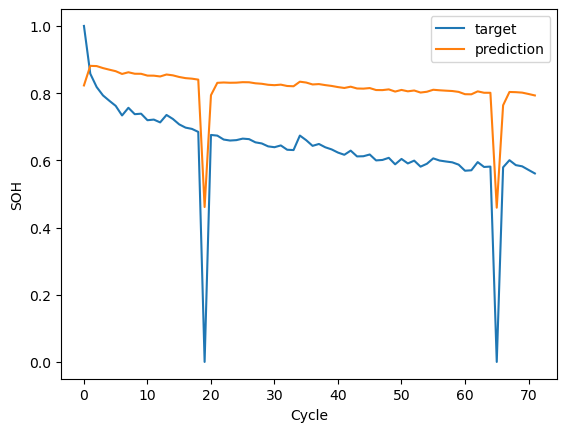

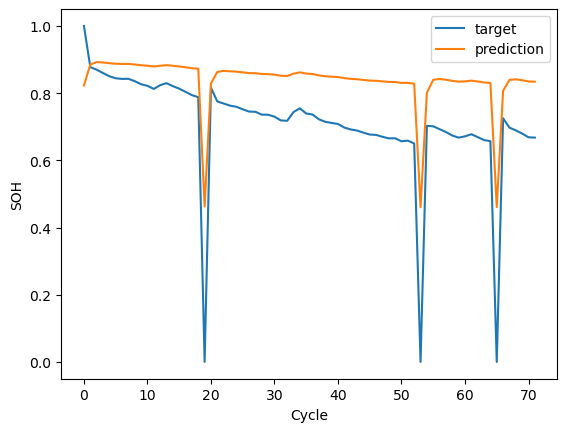

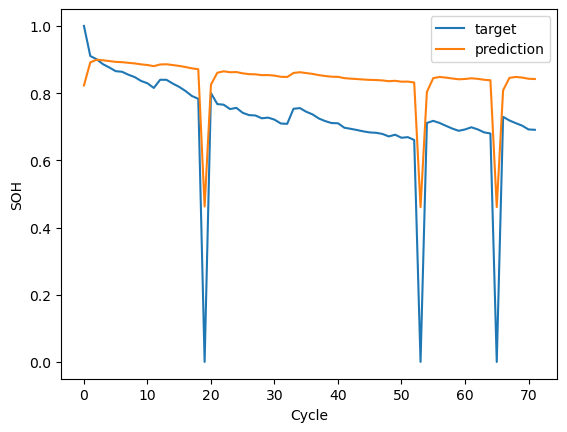

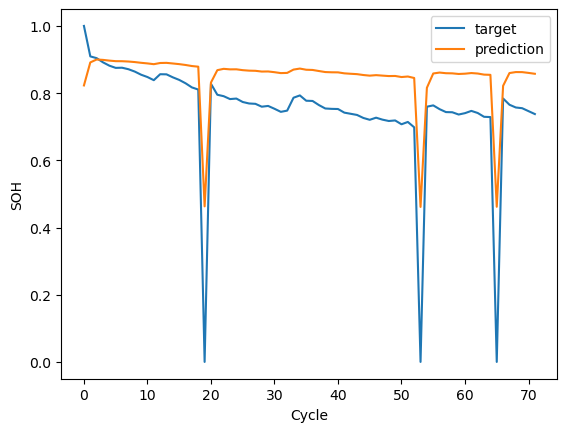

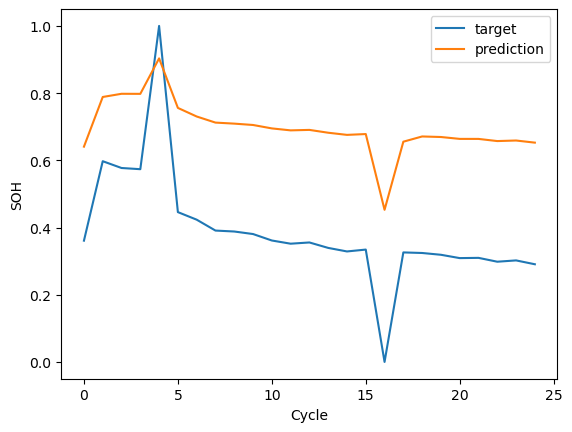

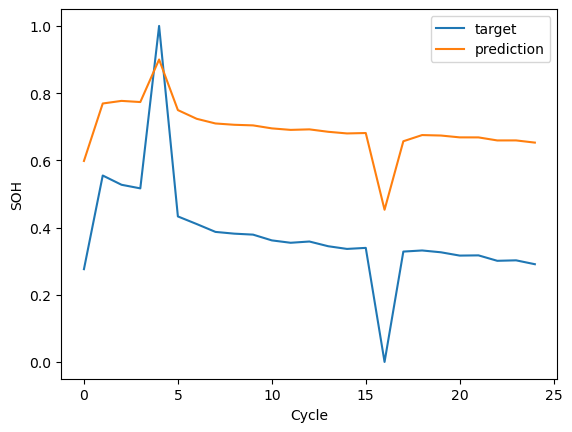

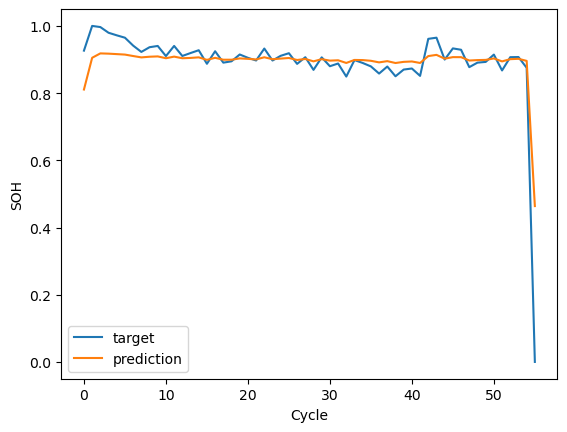

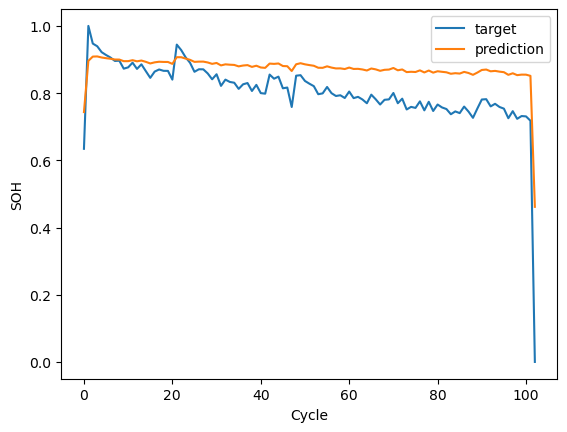

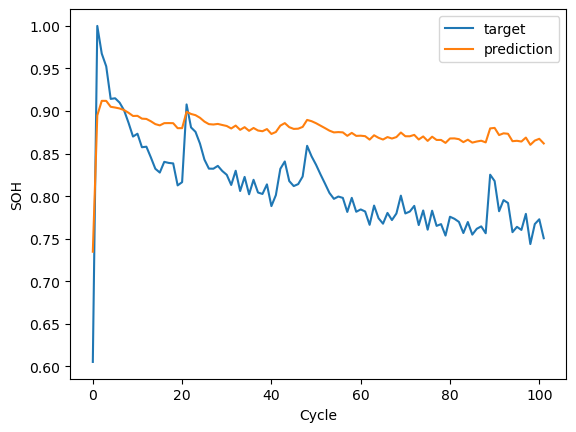

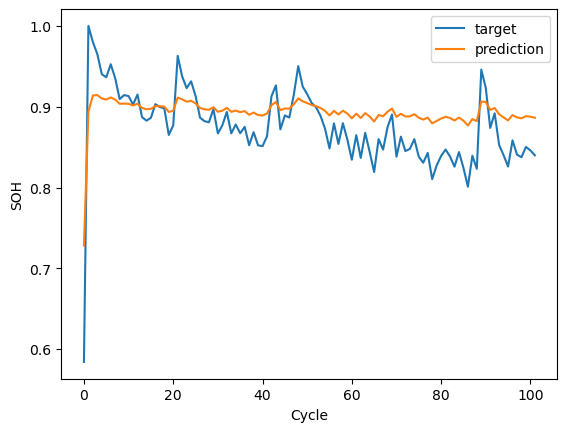

In [35]:
def tensor_seq(data):
    return torch.tensor(data.reshape((len(data),1)), dtype=torch.float32)

def plot_comparison(target, pred, id):
    x = np.arange(0, len(target))
    plt.plot(x, target, label="target")
    plt.plot(x, pred, label="prediction")
    plt.xlabel('Cycle')
    plt.ylabel('SOH')
    plt.legend()
    plt.savefig(id+"_comp.pdf")
    plt.show()

for i, data in enumerate(data_test):
    seq = tensor_seq(data)
    pred = model(seq)
    plot_comparison(seq, pred.detach(), "val"+str(i))

Here we can see the prediction tracks major features in the SOH data reasonably well, but it frequently gets the magnitude of SOH wrong, and also underestimates the rate at which SOH descreases.  However it should be noted this is an extremely simple model - it considers only a single variable and is trained on only 5 timesteps. The model could be made more sophisticated by increasing the length of training sequences, using more variables, increasing the number of recurrent layers, and more...